<a href="https://colab.research.google.com/github/abramhany/flyrank-ml-internship-assignments/blob/main/notebooks/01_first_look_and_discovery.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 1 — Run it, then discover a real truth yourself

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/notebooks/01_first_look_and_discovery.ipynb)

By the end of this notebook you will have:
1. **Run a real ML pipeline** on real (anonymized) search data and watched a learned model beat a hand-written rule.
2. **Rediscovered a real finding yourself** in ~10 lines of pandas.

No prior ML needed. Everything runs on the small anonymized dataset that ships with this repo — no credentials, no private data.

## 0. Setup (Colab or local)
On Colab this clones the repo and installs requirements. Locally it just moves to the repo root.

In [2]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
elif os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")  # move from notebooks/ to the repo root

print("Working dir:", os.getcwd())
assert os.path.exists("data/raw/content_refresh_anonymized.csv"), "starter CSV not found — are you at the repo root?"
print("Starter data found. You're ready.")

Working dir: d:\Programing\flyrank-ml-internship-assignments
Starter data found. You're ready.


## 1. Run the whole pipeline

This runs `scripts/run_all.py`: prepare features → baseline rule → train 3 models → evaluate → PDF.
It takes ~1 minute on the 30,000-row sample.

In [3]:
# Watch it work — each of the 5 steps prints live as it runs (~1 minute total).
!{sys.executable} scripts/run_all.py



▶ Step 1/5 — Prepare features — clean the data, build the feature vector, define the label
Prepared 30,000 rows from 30,000 raw rows
Wrote D:\Programing\flyrank-ml-internship-assignments\data\processed\refresh_feature_vector.csv

▶ Step 2/5 — Baseline — a transparent hand-written rule to beat
Wrote baseline queue: D:\Programing\flyrank-ml-internship-assignments\data\processed\baseline_refresh_queue.csv
Top-50 declining rate (full data, not the evaluated holdout Precision@50): 0.340

▶ Step 3/5 — Train — logistic regression, decision tree, random forest (client-holdout split)
Trained 3 models on 30,000 rows
Split strategy: client_holdout
Best model: random_forest
Wrote predictions: D:\Programing\flyrank-ml-internship-assignments\data\processed\model_predictions.csv
Wrote model results: D:\Programing\flyrank-ml-internship-assignments\outputs\model_results.json

▶ Step 4/5 — Evaluate — ranked refresh queue, charts, and the Markdown report
Wrote final refresh queue: D:\Programing\flyrank-

### What just happened?
The pipeline ranked every page for "refresh review" two ways: a **hand-written rule baseline** and a **learned model**. Let's compare them on **Precision@50** — of the top 50 pages each says to fix first, how many are actually declining?

In [4]:
import json
res = json.load(open("outputs/model_results.json"))

base = res["baseline"]["baseline_precision_at_50"]
rf   = res["models"]["random_forest"]["precision_at_50"]

print(f"Hand-written rule  Precision@50: {base:.3f}   (~{round(base*50)} of the top 50 right)")
print(f"Random forest      Precision@50: {rf:.3f}   (~{round(rf*50)} of the top 50 right)")
print(f"\nThe learned model roughly {rf/base:.1f}x the rule on this metric.")
print("Validation split used:", res["split_strategy"], "(pages from a client are never in both train and test)")

Hand-written rule  Precision@50: 0.240   (~12 of the top 50 right)
Random forest      Precision@50: 0.680   (~34 of the top 50 right)

The learned model roughly 2.8x the rule on this metric.
Validation split used: client_holdout (pages from a client are never in both train and test)


You just ran a real ML system on real search data and saw a learned ranking beat a fixed rule. Now open `outputs/model_report.md` and skim it — that Markdown report is the *shape* of what your own capstone should produce.

## 2. Discover a real truth yourself

The safest, most satisfying early wins are **things you find in the data** — un-leakable, and they *are* the core lesson. Run the three cells below. Each is ~10 lines of pandas and each overturns a common SEO belief.

Every number is **computed live from the shipped CSV** — nothing is hardcoded.

In [5]:
import pandas as pd, numpy as np
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
print(df.shape[0], "rows,", df.shape[1], "columns")
df.head(3)

30000 rows, 44 columns


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 44 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   content_id              30000 non-null  str    
 1   client_id               30000 non-null  str    
 2   search_volume           27532 non-null  float64
 3   competition             27532 non-null  float64
 4   competition_level       27390 non-null  str    
 5   cpc                     27532 non-null  float64
 6   content_type            30000 non-null  str    
 7   main_intent             27626 non-null  str    
 8   word_count              22301 non-null  float64
 9   char_count              22301 non-null  float64
 10  provider_used           8562 non-null   str    
 11  model_used              24267 non-null  str    
 12  impressions_90d         30000 non-null  int64  
 13  clicks_90d              30000 non-null  int64  
 14  pageviews_90d           30000 non-null  int64  
 

In [7]:
df.describe()

,search_volume,competition,cpc,word_count,char_count,impressions_90d,clicks_90d,pageviews_90d,sessions_90d,users_90d,...,sessions_prev_30d,content_age_days,age_tier_order,days_since_last_update,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,trend_pct
count,27532.000000,27532.000000,27532.000000,22301.000000,22301.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.00000,30000.000000,30000.000000,30000.000000,30000.00000,30000.000000,29875.000000,30000.000000,26612.000000
mean,158.882391,0.146954,0.485342,3107.760325,20665.277835,5200.366300,16.097333,49.942467,37.066633,35.937700,...,10.283000,256.16780,4.786533,46.098300,0.510733,16.34238,2.534520,18.212921,0.768196,-4.785969
std,1518.270825,0.285241,2.101560,1452.382598,10115.344042,16838.019547,75.076958,152.101430,107.069131,103.748185,...,42.578003,132.70793,0.790392,42.078709,3.279162,15.21679,8.310096,29.472768,7.429454,473.861780
min,0.000000,0.000000,0.000000,8.000000,40.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,0.000000,90.00000,3.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,-100.000000
25%,0.000000,0.000000,0.000000,2413.000000,15644.000000,81.000000,0.000000,2.000000,2.000000,2.000000,...,1.000000,132.00000,4.000000,20.000000,0.000000,6.20000,0.000000,0.000000,0.000000,-62.600000
50%,10.000000,0.000000,0.000000,2877.000000,19116.000000,731.000000,1.000000,8.000000,7.000000,7.000000,...,2.000000,236.00000,5.000000,20.000000,0.070000,10.80000,0.000000,5.000000,0.000000,-33.500000
75%,20.000000,0.130000,0.000000,3666.000000,24011.000000,3615.250000,7.000000,33.000000,27.000000,27.000000,...,7.000000,333.00000,5.000000,104.000000,0.290000,22.30000,1.350000,23.530000,0.000000,0.000000
max,74000.000000,1.000000,100.360000,9546.000000,111158.000000,517715.000000,4178.000000,5998.000000,4345.000000,4913.000000,...,4247.000000,564.00000,6.000000,373.000000,100.000000,245.00000,100.000000,300.000000,300.000000,44900.000000


### Discovery A — "High search volume means more traffic." Does it?

In [9]:
corr = df["search_volume"].corr(df["impressions_90d"])
print(f"Correlation between search_volume and impressions_90d: {corr:.3f}")
print("Near zero -> keyword search volume barely predicts the traffic a page actually gets.")

Correlation between search_volume and impressions_90d: 0.001
Near zero -> keyword search volume barely predicts the traffic a page actually gets.


### Discovery B — the CTR cliff by position
Click-through rate is not flat: it collapses as you move down the results.

position_tier
page_1      0.3548
top_3       0.3341
striking    0.2558
page_3_5    0.1424
deep        0.0554


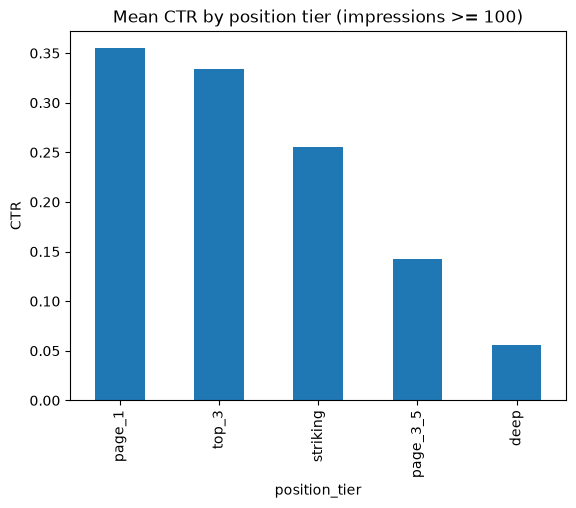

In [10]:
visible = df[df["impressions_90d"] >= 100]
ctr_by_pos = visible.groupby("position_tier")["ctr"].mean().sort_values(ascending=False)
print(ctr_by_pos.round(4).to_string())
ctr_by_pos.plot(kind="bar", title="Mean CTR by position tier (impressions >= 100)", ylabel="CTR");

### Discovery C — is longer content the lever?
Compare word count for **declining** vs **growing** pages.

In [11]:
wc = df.groupby("trend_direction")["word_count"].median()
print(wc.round(0).to_string())
print("\n'down' vs 'up' pages have almost the same median word count -> length is not the lever.")

trend_direction
down      2909.0
flat      2698.0
new       2239.0
stable    2912.0
up        2848.0

'down' vs 'up' pages have almost the same median word count -> length is not the lever.


## 3. 🔧 Your turn

Pick **one** of these and write a few lines below. This is your Week-1 discovery — you'll reference it in your Week-1 research-question write-up (on the InternHQ board).

- Redo Discovery A but only for pages with `impressions_90d > 0` — does the correlation change?
- In Discovery B, which `content_type` has the worst CTR *at the same position tier*?
- Find another belief to test: does `content_age_days` relate to `trend_direction`? Does `avg_position` relate to `ctr`?

**Rules:** describe what you observe as *observed / directional* — never "I proved Google's algorithm." Keep client data out of anything you publish.

In [12]:
# Your discovery here
new_df = df[df['impressions_90d']>0]
corr = new_df["search_volume"].corr(new_df["impressions_90d"])
print(f"Correlation between search_volume and impressions_90d: {corr:.3f}")

Correlation between search_volume and impressions_90d: 0.001


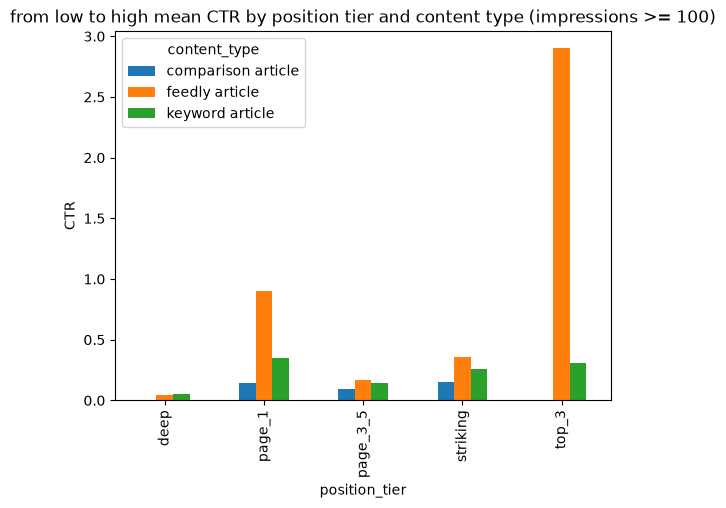

In [13]:
visible = df[df["impressions_90d"] >= 100]
grouped = visible.groupby(["position_tier", "content_type"])['ctr'].mean().unstack()
grouped.plot(kind="bar", title="from low to high mean CTR by position tier and content type (impressions >= 100)", ylabel="CTR");

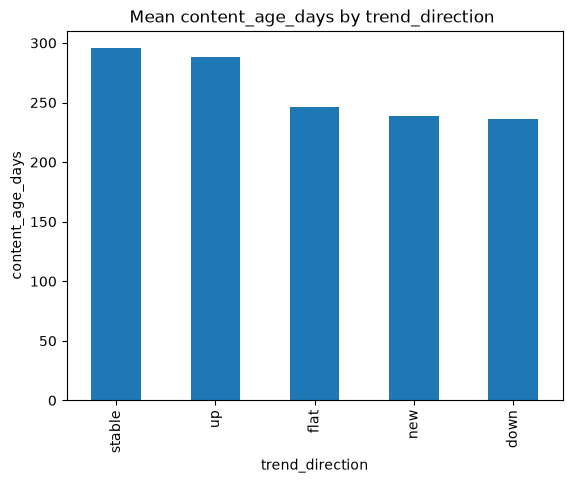

In [14]:
#Find another belief to test: does content_age_days relate to trend_direction? Does avg_position relate to ctr?
trend_group = df.groupby('trend_direction')['content_age_days'].mean().sort_values(ascending=False)
trend_group
trend_group.plot(kind="bar", title="Mean content_age_days by trend_direction ", ylabel="content_age_days");

In [15]:
corr = df["ctr"].corr(df["avg_position"])
print(f"Correlation between ctr and avg_position: {corr:.3f}")

Correlation between ctr and avg_position: -0.073


<Axes: xlabel='age_tier'>

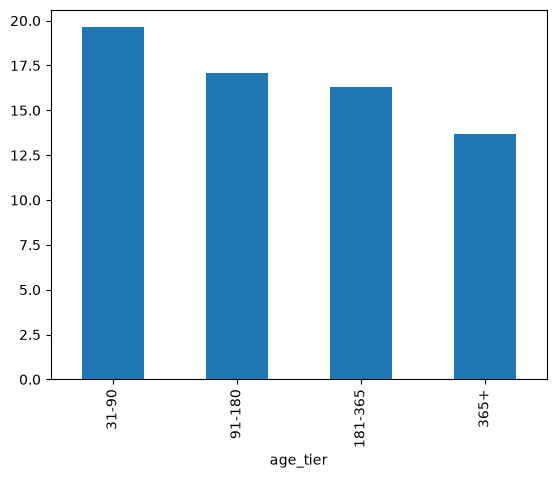

In [16]:
group = df.groupby(['age_tier'])['clicks_90d'].mean().sort_values(ascending=False)
group.plot(kind="bar")

In [ ]:
# Filter out the "dead" pages that have less than 100 impressions in the last 90 days
visible_pages = df[df['impressions_90d'] >= 100]

# Now, use visible_pages for your analysis instead of the raw df!
print(f"Original rows: {len(df)}")
print(f"Trustworthy rows: {len(visible_pages)}")

Original rows: 30000
Trustworthy rows: 22006


In [ ]:
# Quick check of missingness
print(visible_pages.isna().sum().sort_values(ascending=False))

provider_used             15824
word_count                 6555
char_count                 6555
word_count_tier            6555
char_count_tier            6555
model_used                 5311
competition_level           679
cpc                         565
competition                 565
search_volume               565
main_intent                 494
trend_pct                   248
scroll_rate                  27
content_type                  0
impressions_90d               0
clicks_90d                    0
pageviews_90d                 0
sessions_90d                  0
days_with_impressions         0
days_with_sessions            0
impressions_last_30d          0
clicks_last_30d               0
users_90d                     0
engaged_sessions_90d          0
ai_sessions_90d               0
scroll_events_90d             0
sessions_prev_30d             0
clicks_prev_30d               0
impressions_prev_30d          0
sessions_last_30d             0
days_since_last_update        0
age_tier

In [ ]:
valid_trends = ['down', 'stable', 'up']
filtered_data = visible_pages[visible_pages['trend_direction'].isin(valid_trends)]
filtered_data.info()

<class 'pandas.DataFrame'>
Index: 21758 entries, 0 to 29999
Data columns (total 42 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   search_volume           21201 non-null  float64
 1   competition             21201 non-null  float64
 2   competition_level       21087 non-null  str    
 3   cpc                     21201 non-null  float64
 4   content_type            21758 non-null  str    
 5   main_intent             21272 non-null  str    
 6   word_count              15227 non-null  float64
 7   char_count              15227 non-null  float64
 8   provider_used           6143 non-null   str    
 9   model_used              16448 non-null  str    
 10  impressions_90d         21758 non-null  int64  
 11  clicks_90d              21758 non-null  int64  
 12  pageviews_90d           21758 non-null  int64  
 13  sessions_90d            21758 non-null  int64  
 14  users_90d               21758 non-null  int64  
 15  e

In [ ]:
print(filtered_data.describe())

       search_volume   competition           cpc    word_count     char_count  \
count   21201.000000  21201.000000  21201.000000  15227.000000   15227.000000   
mean      165.923306      0.142665      0.462913   3342.846194   22000.727655   
std      1638.996186      0.279494      1.863728   1471.026607    9992.620085   
min         0.000000      0.000000      0.000000    675.000000    4629.000000   
25%         0.000000      0.000000      0.000000   2574.000000   16726.500000   
50%        10.000000      0.000000      0.000000   2923.000000   19286.000000   
75%        20.000000      0.120000      0.000000   3777.500000   24757.500000   
max     74000.000000      1.000000     46.630000   9546.000000  109458.000000   

       impressions_90d    clicks_90d  pageviews_90d  sessions_90d  \
count     21758.000000  21758.000000   21758.000000  21758.000000   
mean       7144.551383     22.107501      67.100423     49.471321   
std       19417.331715     87.404551     175.510164    123.4015

In [ ]:
filtered_data['trend_direction'].value_counts(normalize=True)

trend_direction
down      0.604467
stable    0.240463
up        0.155069
Name: proportion, dtype: float64

In [ ]:
summary = filtered_data.groupby("trend_direction")[["impressions_90d", "clicks_90d", "ctr", "avg_position", "engagement_rate"]].mean()
summary

,impressions_90d,clicks_90d,ctr,avg_position,engagement_rate
trend_direction,,,,,
down,6074.179745,16.481296,0.229380,15.991423,2.653187
stable,10494.318998,38.875191,0.315182,16.328479,3.002636
up,6122.483699,18.037344,0.277599,23.616953,3.207792


C:\Users\abram\AppData\Local\Temp\ipykernel_1508\2957234604.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=filtered_data, x='trend_direction', y='ctr', order=valid_trends, ax=axes[0], palette='Reds')
C:\Users\abram\AppData\Local\Temp\ipykernel_1508\2957234604.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=filtered_data, x='trend_direction', y='engagement_rate', order=valid_trends, ax=axes[1], palette='Blues')


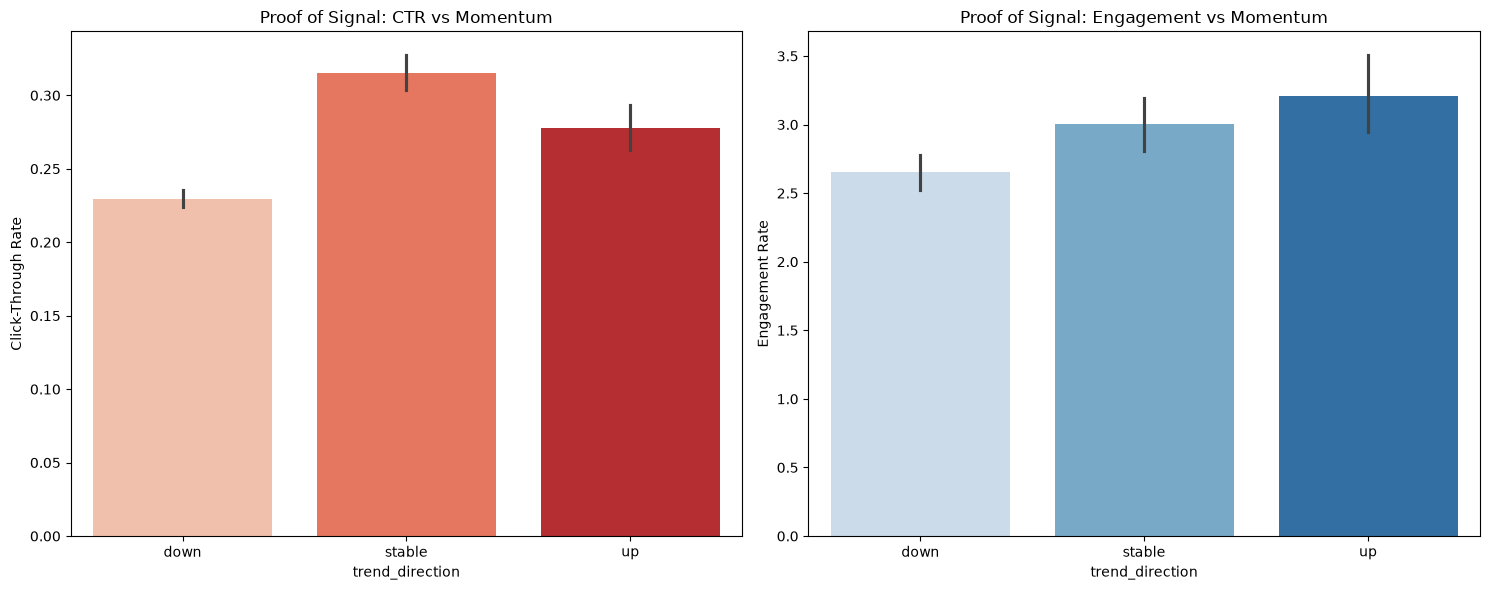

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))


sns.barplot(data=filtered_data, x='trend_direction', y='ctr', order=valid_trends, ax=axes[0], palette='Reds')
axes[0].set_title('Proof of Signal: CTR vs Momentum')
axes[0].set_ylabel('Click-Through Rate')

# Plot 2: Engagement Rate
sns.barplot(data=filtered_data, x='trend_direction', y='engagement_rate', order=valid_trends, ax=axes[1], palette='Blues')
axes[1].set_title('Proof of Signal: Engagement vs Momentum')
axes[1].set_ylabel('Engagement Rate')

plt.tight_layout()
plt.show()

In [ ]:
print(filtered_data.groupby(['trend_direction','content_type'])['ctr'].median())

trend_direction  content_type      
down             comparison article    0.000
                 feedly article        0.190
                 keyword article       0.130
stable           comparison article    0.000
                 feedly article        0.345
                 keyword article       0.200
up               comparison article    0.000
                 feedly article        0.270
                 keyword article       0.150
Name: ctr, dtype: float64


In [ ]:
filtered_data['content_type'].value_counts(normalize='index')


content_type
keyword article       0.967322
comparison article    0.016821
feedly article        0.015856
Name: proportion, dtype: float64

                       mean  median
trend_direction                    
down             237.937348   221.0
stable           300.750191   309.0
up               294.628927   306.0


<Axes: xlabel='trend_direction', ylabel='content_age_days'>

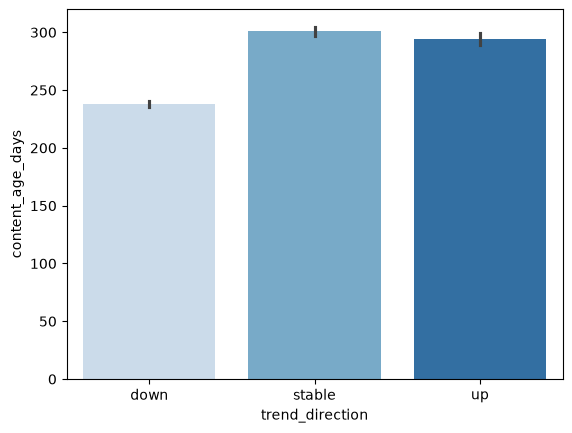

In [ ]:
print(filtered_data.groupby(['trend_direction'])['content_age_days'].agg(['mean','median']))
sns.barplot(data=filtered_data,x='trend_direction',y='content_age_days',hue='trend_direction',order=valid_trends, palette='Blues')


In [ ]:
age_proof = pd.crosstab(
    index=filtered_data['age_tier'], 
    columns=filtered_data['trend_direction'], 
    normalize='index' 
)

print(age_proof.mul(100).round(1))

trend_direction  down  stable    up
age_tier                           
181-365          60.8    25.1  14.1
31-90            68.3    14.2  17.5
365+             42.9    34.5  22.6
91-180           70.8    16.9  12.3


In [ ]:
print(filtered_data.groupby(['trend_direction'])['days_since_last_update'].agg(['mean','median']))

print("the more days it take's to update a page the more likely to fail ")

                      mean  median
trend_direction                   
down             51.998251    22.0
stable           52.148700    22.0
up               45.916123    22.0


In [ ]:
print(filtered_data.groupby(['trend_direction'])['search_volume'].agg(['mean','median']))

                       mean  median
trend_direction                    
down             130.729370    10.0
stable           209.511765    10.0
up               236.101591    10.0


In [ ]:
n = len(filtered_data)
counts = filtered_data['trend_direction'].value_counts()
pct_down = 100 * counts.get('down', 0) / n

print(f"Rows after filters: {n}")
print(f"Pages with trend 'down': {counts.get('down',0)} ({pct_down:.1f}%)\n")

print("Median impressions_90d by trend:")
print(filtered_data.groupby('trend_direction')['impressions_90d'].median().to_string(), "\n")

print("Median days_since_last_update by trend:")
print(filtered_data.groupby('trend_direction')['days_since_last_update'].mean().to_string())

Rows after filters: 21758
Pages with trend 'down': 13152 (60.4%)

Median impressions_90d by trend:
trend_direction
down      1620.5
stable    2642.0
up        1073.0 

Median days_since_last_update by trend:
trend_direction
down      51.998251
stable    52.148700
up        45.916123


### Save your work
**Colab:** *File → Save a copy in GitHub* (writes to your own repo — that's your submission) and *File → Save a copy in Drive* (so the session doesn't evaporate).

Next: `02_your_first_readable_model.ipynb` — where the model becomes a rule you can read.